# t-SNE Analysis: In Vivo vs In Vitro Enzyme-Substrate Space

This notebook demonstrates the complete pipeline for comparing in vivo and in vitro enzyme datasets using t-SNE visualization.

## Objectives
- **Coverage**: Are in vitro and in vivo entries populating the same biochemical neighborhoods?
- **Gaps**: Which regions have only in vivo (no assays) or only in vitro (no in vivo estimate)?
- **Local comparison**: In regions where both exist, do in vivo values run systematically lower than in vitro?

## Pipeline Overview
1. Get protein embeddings from ESM-2 650M (1280-d, cached per unique sequence)
2. Get substrate embeddings from RDKit ECFP6 (Morgan count fingerprint, radius=3, nBits=2048)
3. Concatenate and scale [protein_embed || substrate_ecfp]
4. PCA reduction to 50–128 dims for denoising & speed
5. t-SNE mapping with color coding by dataset (in vitro vs in vivo)
6. Coverage analysis to identify gaps and overlaps


In [ ]:
# automatic module reloading
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append('../scripts')

# import complete pipeline
from tsne_kcats import run_tsne_pipeline_invivo_invitro

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Pipeline imported successfully!")

Pipeline imported successfully!


## Check Data Overview


In [2]:
# Load and examine the datasets
all_seqs = pd.read_csv('../data/processed/experiments/all_seqs_smiles.csv')
kmax_data = pd.read_csv('../data/processed/experiments/kmax_clean.csv')  # in vivo
catpred_data = pd.read_csv('../data/processed/experiments/catpred_clean.csv')  # in vitro

print("Dataset Overview:")
print(f"All unique (sequence, SMILES) pairs: {len(all_seqs)}")
print(f"In vivo (kmax) entries: {len(kmax_data)}")
print(f"In vitro (catpred) entries: {len(catpred_data)}")
print(f"Unique sequences in all_seqs: {all_seqs['sequence'].nunique()}")
print(f"Unique SMILES in all_seqs: {all_seqs['SMILES'].nunique()}")

# Show sample data
print("\nSample from all_seqs_smiles.csv:")
print(all_seqs.head())

print("\nSample from kmax_clean.csv:")
print(kmax_data.head())

print("\nSample from catpred_clean.csv:")
print(catpred_data.head())


Dataset Overview:
All unique (sequence, SMILES) pairs: 1964
In vivo (kmax) entries: 389
In vitro (catpred) entries: 1579
Unique sequences in all_seqs: 522
Unique SMILES in all_seqs: 1070

Sample from all_seqs_smiles.csv:
                                            sequence  \
0  MMITLRKLPLAVAVAAGVMSAQAMAVDFHGYARSGIGWTGSGGEQQ...   
1  MDFSLTEEQELLLASIRELITTNFPEEYFRTCDQNGTYPREFMRAL...   
2  MDFSLTEEQELLLASIRELITTNFPEEYFRTCDQNGTYPREFMRAL...   
3  MPNITWCDLPEDVSLWPGLPLSLSGDEVMPLDYHAGRSGWLLYGRG...   
4  MLKYRLISAFVLIPVVIAALFLLPPVGFAIVTLVVCMLAAWEWGQL...   

                                              SMILES  
0             O=C[C@H](O)[C@@H](O)[C@H](O)[C@H](O)CO  
1  C/C=C/C(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)...  
2  Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...  
3           [NH3+][C@@H](COP(=O)([O-])[O-])C(=O)[O-]  
4  CCCCCCC=CCCCCCCCC(=O)OCC(COP(=O)([O-])O)OC(=O)...  

Sample from kmax_clean.csv:
                                            sequence  \
0  MMITLRKLPLAVAVAAGVMSAQAM

## Install Required Dependencies

Note: You need to install the required packages before running the pipeline:


In [3]:
# Uncomment and run if you need to install dependencies
# !pip install fair-esm torch rdkit-pypi scikit-learn matplotlib seaborn pandas numpy

# Check if ESM is available
try:
    import esm
    print("ESM is available")
except ImportError:
    print("ESM not available. Install with: pip install fair-esm")

# Check if RDKit is available  
try:
    from rdkit import Chem
    print("RDKit is available")
except ImportError:
    print("RDKit not available. Install with: pip install rdkit-pypi")


ESM is available
RDKit is available


## Run Complete t-SNE Pipeline

This will execute all steps of the pipeline:
1. Compute protein embeddings (cached)
2. Compute substrate embeddings
3. Combine and scale embeddings
4. Apply PCA reduction
5. Generate t-SNE visualization
6. Analyze coverage patterns


=== Starting t-SNE Pipeline ===
Loading datasets...
All sequences: 1964 entries
In vivo (kmax): 389 entries
In vitro (catpred): 1579 entries

=== Step 1: Computing protein embeddings ===
Computing embeddings for 522 unique sequences...
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /home/chinasse/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /home/chinasse/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt
No cache found. Computing embedding for sequence: MMITLRKLPLAVAVAAGVMSAQAMAVDFHGYARSGIGWTGSGGEQQCFQTTGAQSKYRLGNECETYAELKLGQEVWKEGDKSFYFDTNVAYSVAQQNDWEATDPAFREANVQGKNLIEWLPGSTIWAGKRFYQRHDVHMIDFYYWDISGPGAGLENIDVGFGKLSLAATRSSEAGGSSSFASNNIYDYTNETANDVFDVRLAQMEINPGGTLELGVDYGRANLRDNYRLVDGASKDGWLFTAEHTQSVLKGFNKFVVQYATDSMTSQGKGLSQGSGVAFDNEKFAYNINNNGHMLRILDHGAISMGDNWDMMYVGMYQDINWDNDNGTKWWTVGIRPMYKWTPIMSTVMEIGYDNVESQRTG

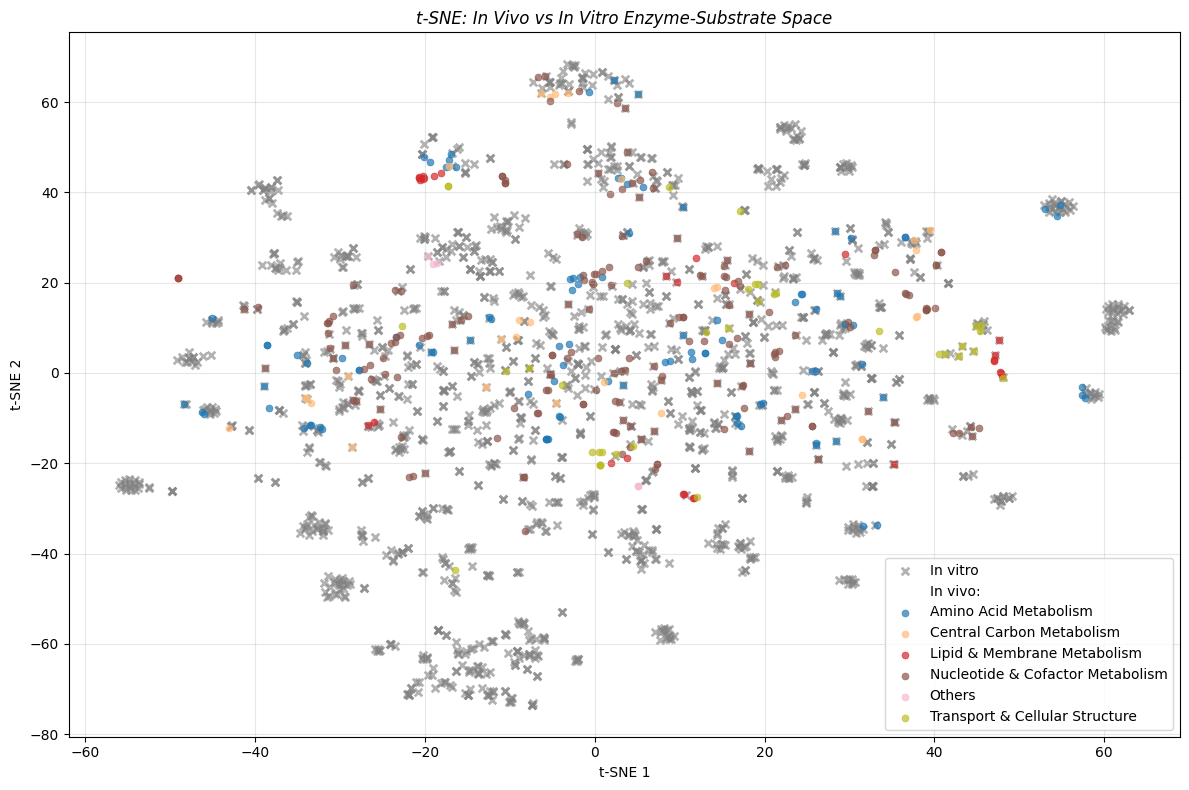

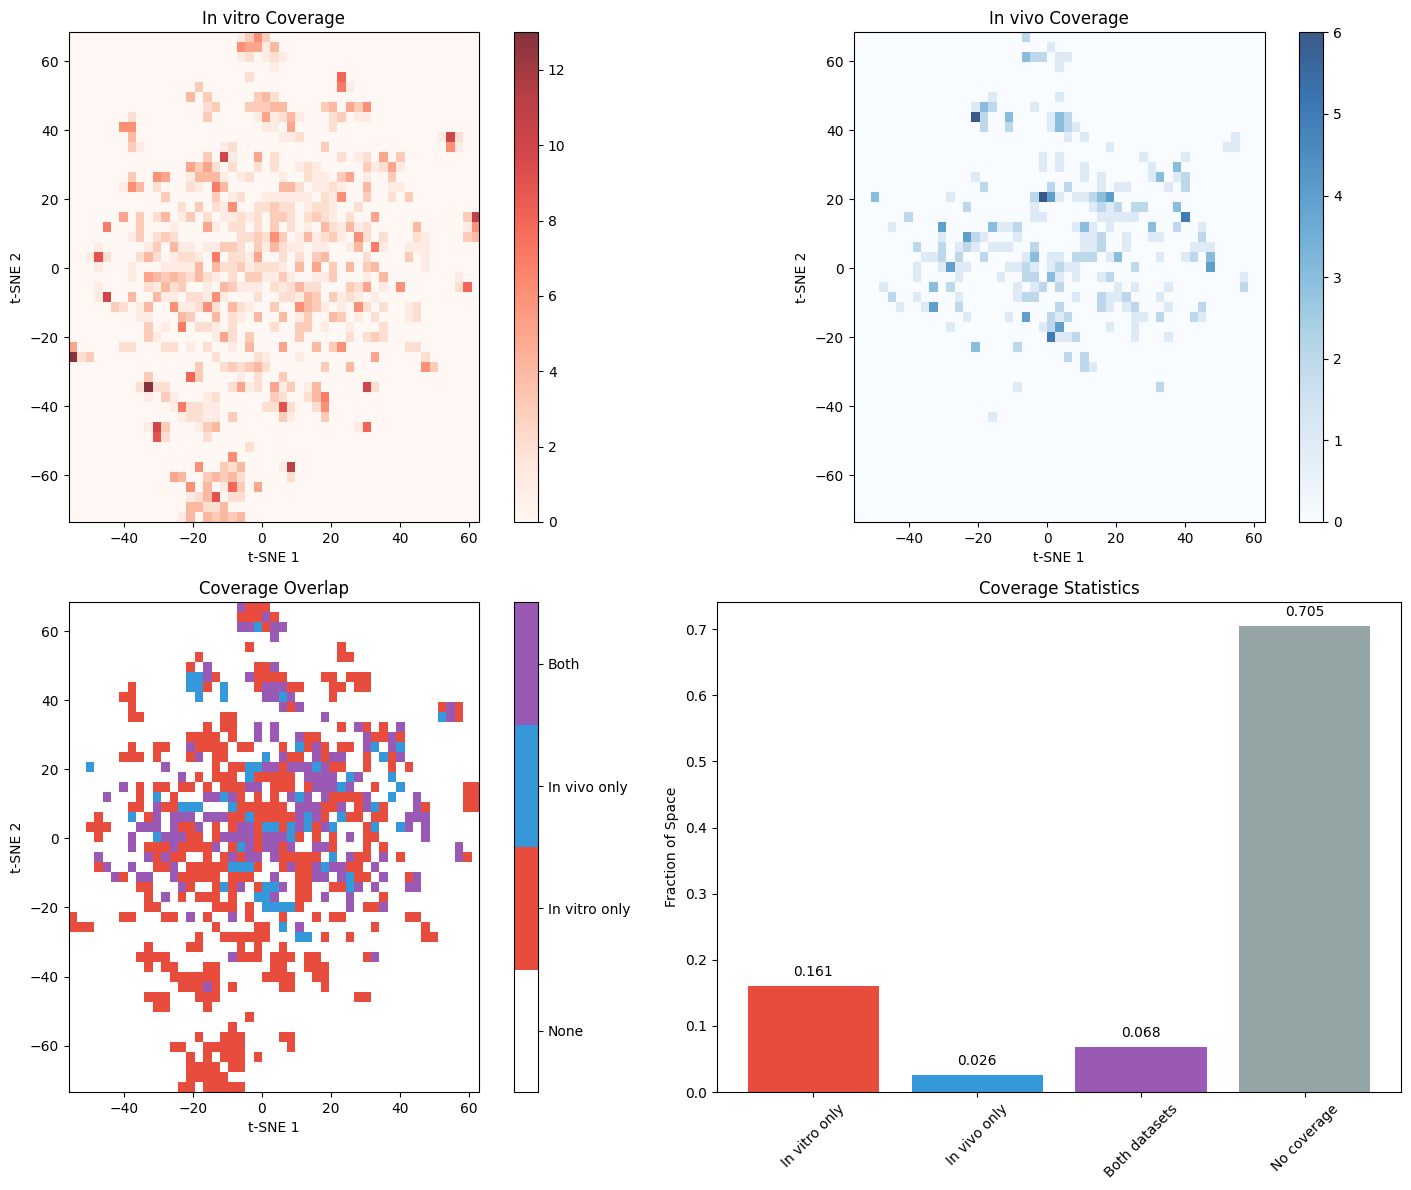

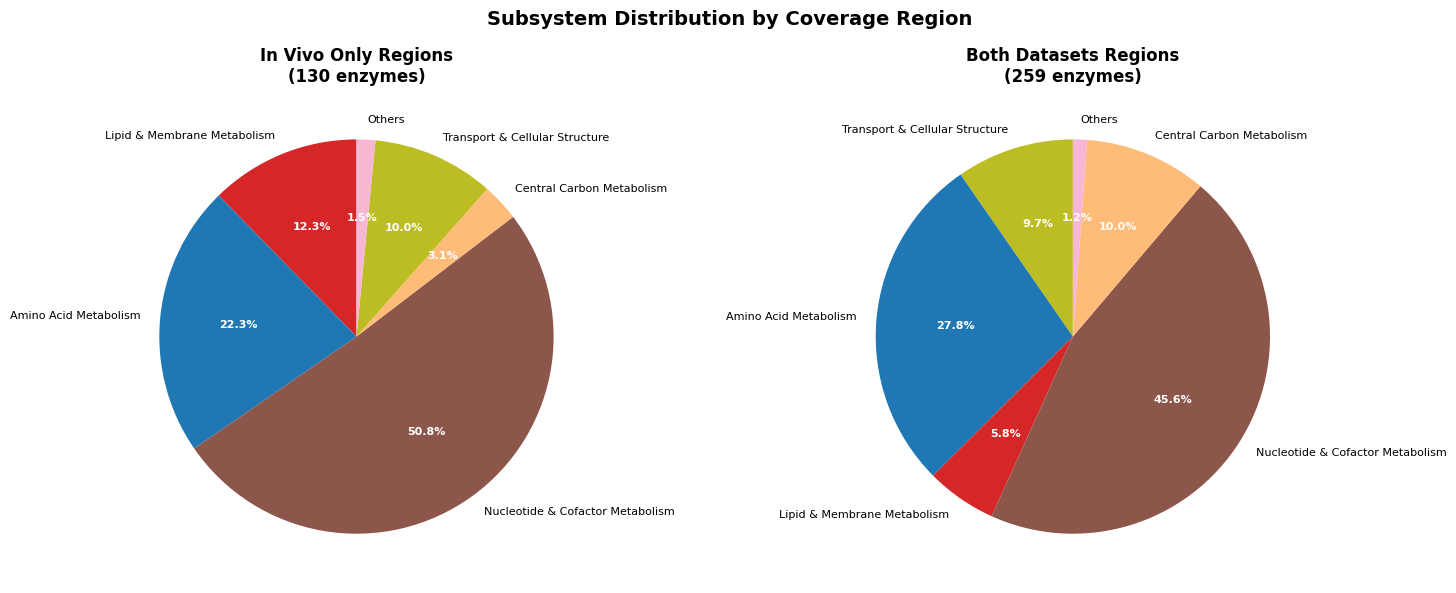

In [ ]:
# Run the complete pipeline
results = run_tsne_pipeline(
    all_seqs_file="../data/processed/experiments/all_seqs_smiles.csv",
    kmax_file="../data/processed/experiments/kmax_clean.csv",
    catpred_file="../data/processed/experiments/catpred_clean.csv",
    output_dir="../results/tsne_analysis",
    pca_components=100,  # You can adjust this (50-128 recommended)
    cache_dir="../cache"
)


# Code for input csvs (in vitro kcat and kmax)

In [31]:
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cobra

cobra.Configuration().solver = "cplex"

# Add paths
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../scripts'))

# Add directories
data_dir = "../data"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
# kmax
kamx_dir = os.path.join(data_dir, "final", "kcat_app", "iml1515_homomeric_kmax.csv")
df_kmax = pd.read_csv(kamx_dir)

# cpi and catpred
CatPred_dir = os.path.join(data_dir, "processed", "CatPred", "catpred_single_subs.csv")
df_catpred = pd.read_csv(CatPred_dir)

In [33]:
from scripts.kcat_utils import canonicalize

# canonicalize
df_kmax['SMILES_canon'] = df_kmax['SMILES'].apply(canonicalize)
df_catpred['SMILES_canon'] = df_catpred['SMILES'].apply(canonicalize)

# clean
df_kmax.drop(columns=['SMILES'], inplace=True)
df_catpred.drop(columns=['SMILES'], inplace=True)

df_kmax.rename(columns={'SMILES_canon': 'SMILES'}, inplace=True)
df_catpred.rename(columns={'SMILES_canon': 'SMILES'}, inplace=True)

In [34]:
all_seqs_smiles = (
    pd.concat([
        df_kmax[["sequence", "SMILES"]],
        df_catpred[["sequence", "SMILES"]]
    ], ignore_index=True)
)

print(len(all_seqs_smiles))

1968


In [35]:
# drop duplicates
all_seqs_smiles = all_seqs_smiles.drop_duplicates(subset=["sequence", "SMILES"])
print(len(all_seqs_smiles))

1964


In [36]:
all_seqs_smiles.to_csv(os.path.join(data_dir, "processed", "experiments", "all_seqs_smiles.csv"), index=False)

In [37]:
# clean dataframes of kmax and catpred
df_kmax_clean = df_kmax[["sequence", "SMILES", "subsystem","kcat_app_max"]].copy()
df_kmax_clean.rename(columns={"kcat_app_max": "kcat_invivo"}, inplace=True)

df_catpred_clean = df_catpred[["sequence", "SMILES", "kcat_CatPred"]].copy()
df_catpred_clean.rename(columns={"kcat_CatPred": "kcat_invitro"}, inplace=True)


In [38]:
df_kmax_clean.to_csv(os.path.join(data_dir, "processed", "experiments","kmax_clean.csv"), index=False)
df_catpred_clean.to_csv(os.path.join(data_dir, "processed", "experiments","catpred_clean.csv"), index=False)

## Collapsing subsystems

In [39]:
df_subsystems_unique = df_kmax_clean['subsystem'].unique()

In [40]:
print(df_subsystems_unique)

['Transport, Outer Membrane' 'Membrane Lipid Metabolism'
 'Glycine and Serine Metabolism' 'Glycerophospholipid Metabolism'
 'Valine, Leucine, and Isoleucine Metabolism'
 'Threonine and Lysine Metabolism'
 'Cofactor and Prosthetic Group Biosynthesis' 'Pentose Phosphate Pathway'
 'Glycolysis/Gluconeogenesis' 'Purine and Pyrimidine Biosynthesis'
 'Anaplerotic Reactions' 'Alternate Carbon Metabolism'
 'Lipopolysaccharide Biosynthesis / Recycling'
 'Arginine and Proline Metabolism' 'Citric Acid Cycle' 'Folate Metabolism'
 'Nucleotide Salvage Pathway' 'Inorganic Ion Transport and Metabolism'
 'Cysteine Metabolism'
 'Tyrosine, Tryptophan, and Phenylalanine Metabolism'
 'Transport, Inner Membrane' 'Cell Envelope Biosynthesis'
 'Glutamate Metabolism' 'Methionine Metabolism' 'Histidine Metabolism'
 'tRNA Charging' 'Oxidative Phosphorylation']


In [41]:
# Create mapping dictionary - assessment with help of an LLM
subsystem_mapping = {
    # Central Carbon Metabolism
    'Glycolysis/Gluconeogenesis': 'Central Carbon Metabolism',
    'Citric Acid Cycle': 'Central Carbon Metabolism',
    'Pentose Phosphate Pathway': 'Central Carbon Metabolism',
    'Anaplerotic Reactions': 'Central Carbon Metabolism',
    'Alternate Carbon Metabolism': 'Central Carbon Metabolism',
    
    # Amino Acid Metabolism
    'Glycine and Serine Metabolism': 'Amino Acid Metabolism',
    'Valine, Leucine, and Isoleucine Metabolism': 'Amino Acid Metabolism',
    'Threonine and Lysine Metabolism': 'Amino Acid Metabolism',
    'Arginine and Proline Metabolism': 'Amino Acid Metabolism',
    'Cysteine Metabolism': 'Amino Acid Metabolism',
    'Tyrosine, Tryptophan, and Phenylalanine Metabolism': 'Amino Acid Metabolism',
    'Glutamate Metabolism': 'Amino Acid Metabolism',
    'Methionine Metabolism': 'Amino Acid Metabolism',
    'Histidine Metabolism': 'Amino Acid Metabolism',
    
    # Nucleotide & Cofactor Metabolism
    'Purine and Pyrimidine Biosynthesis': 'Nucleotide & Cofactor Metabolism',
    'Nucleotide Salvage Pathway': 'Nucleotide & Cofactor Metabolism',
    'Cofactor and Prosthetic Group Biosynthesis': 'Nucleotide & Cofactor Metabolism',
    'Folate Metabolism': 'Nucleotide & Cofactor Metabolism',
    
    # Lipid & Membrane Metabolism
    'Membrane Lipid Metabolism': 'Lipid & Membrane Metabolism',
    'Glycerophospholipid Metabolism': 'Lipid & Membrane Metabolism',
    'Lipopolysaccharide Biosynthesis / Recycling': 'Lipid & Membrane Metabolism',
    
    # Transport & Cellular Structure
    'Transport, Outer Membrane': 'Transport & Cellular Structure',
    'Transport, Inner Membrane': 'Transport & Cellular Structure',
    'Cell Envelope Biosynthesis': 'Transport & Cellular Structure',
    'Inorganic Ion Transport and Metabolism': 'Transport & Cellular Structure',
    
    # Others
    'tRNA Charging': 'Others',
    'Oxidative Phosphorylation': 'Others'
}

In [42]:
# Apply mapping to create new column
df_kmax_clean['subsystem'] = df_kmax_clean['subsystem'].map(subsystem_mapping)

In [43]:
df_kmax_clean.to_csv(os.path.join(data_dir, "processed", "experiments","kmax_clean.csv"), index=False)
